
<p style="font-size:1.25em;"> Ce notebook a pour objectif de fournir rapidement : <br> <strong> Le paramètre d’ordre nématique moyen</strong> <strong>
et les pics de corrélation</strong> à partir d’un dossier contenant des fichiers <strong>H5</strong>. </p>

<span style="font-size: 1.4em; font-weight: 700;"> Fonctionnalités principales</span>
<p style="font-size:1.15em;">

Calcul des intensités moyennes du dossier

Extraction des pics de corrélation

Détermination du paramètre d’ordre sur la valeur de q du premier pic

Importation de l'image de diffusion moyenne,
avec tracé automatique des cercles correspondant aux différents pics

</p>


In [1]:
%matplotlib widget
from utilities_SWING import *
import pandas as pd

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "c:\Users\saram\anaconda3\envs\debye3d_env\Lib\asyncio\base_events.py", line 608, in run_forever
    self._run_once()
  File "c:\Users\saram\anaconda3\envs\debye3d_env\Lib\asyncio\base_events.py", line 1936, in _run_once
    handle._run()
  File "c:\Users\saram\anaconda3\envs\debye3d_env\Lib\asyncio\events

**Definition of path, mask file, and output directory (optional)**

In [2]:
pathh5 =  'test_data/SWING_fev2026/example_emma_rods/' # path to the folder containing the h5 files 
fileh5 = 'test_data/SWING_fev2026/example_emma_rods/lacroix_00180_2026-02-06_14-31-57.nxs' # path to the h5 file you want to analyze
mask = "test_data/SWING_fev2026/mask_pyfai_nico.edf" # mask generated by Nicolas directly (edf format)
instrument='SWING'
output_dir='./test_output/'
os.makedirs(output_dir,exist_ok=True)

##### **Change the format of the mask: from txt to edf (already done)**

In [3]:
# # Convert mask from SWING mask (just to show it is possible)
# file = h5File_SWING(fileh5,mean = True)
# mask = file.convert_SWING_mask(maskfile = mask_txt)


### **Make an instance of the SAXSProcessor class**

 **New feature: find automatically the beackground reference file and the form factor parameters: diameter, length, polydispersity of both [%]**


It is now possible to use **get_all_params()** from the module **excel_parameters_extractor** to find :
- the reference background file that will be used when creating the instance of the module **SAXSProcessor()**
- the geometric parameters (d,L, polydisp) that will be used in **compute_nematic_parameter()**



Parameters:

- *excel_file* : (str)
    Path to the excel file.
- *bg_path* : (str)
    Path to the folder containing the reference files.
- *h5path* : (str)
    Path to the folder containing the h5 files.

Returns:

- *diameter*: (float)
    Diameter in nm.
- *length*: (float)
    Length in nm.
- *polydispersity_d*: (float)
    Polydispersity of the diameter in [%].
- *polydispersity_L*: (float)
    Polydispersity of the length in [%].
- *reference_file*: (str)
    Path of the reference file.

*Notes: the excel file must contain the indexes of the h5 files, for example: for files lacroix_00782_2024-07-20_02-32-08.h5, the index they must be written as "00782" in the "FILE" column of the excel.* 

In [4]:
from excel_parameters_extractor import get_all_params

excel_file = "Run_synchrotron_SOLEIL_02_2026_suivi_manips.xlsm" # path to the excel file containing the parameters 
bg_path = "test_data/SWING_fev2026/example_emma_rods" # path of the folder containing the background files (probably the same as the folder containing the h5 files)
fileh5 = 'test_data/SWING_fev2026/example_emma_rods/lacroix_00180_2026-02-06_14-31-57.nxs' # your path to the h5 file you want to analyze


diameter, polydispersity_d, length, polydispersity_L, reference_file  = get_all_params(excel_file, bg_path, fileh5) # here specify the measurement name

print("Extracted parameters from excel:")
print(f"Diameter: {diameter} nm")
print(f"Polydispersity on diameter: {polydispersity_d} %")
print(f"Length: {length} nm")
print(f"Polydispersity on length: {polydispersity_L} %")
print(f"Reference file: {reference_file}") 


Measurement name found: M0119 for index of h5 file 180.0
Extracted parameters from excel:
Diameter: 18.3 nm
Polydispersity on diameter: 14.207650273224044 %
Length: 152.988 nm
Polydispersity on length: 15.69 %
Reference file: test_data/SWING_fev2026/example_emma_rods\lacroix_00179_2026-02-06_14-04-10.nxs


c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [5]:
# If no reference file, you can set reference_file to None:
#proc = SAXSProcessor(instrument=instrument ,file=fileh5, mask=mask) 

# If you have the reference file extracted from the previous function, use it to automatically subtract the background:
proc = SAXSProcessor(instrument=instrument,reference_file=reference_file ,autosubstract=True,file=fileh5, mask=mask)

position moteur :
{'X_start': array([36.6997]), 'X_end': array([38.5999]), 'Z_start': array([39.4995]), 'Z_end': array([41.4003])}
{'X_start': array([36.6997]), 'X_end': array([38.5999]), 'Z_start': array([39.4995]), 'Z_end': array([41.4003])}
step :
[0.09501]
[0.09504]
1
Raw data shape: (20, 20, 1083, 1035)
info
1083
1035
position moteur :
{'X_start': array([36.6997]), 'X_end': array([38.6]), 'Z_start': array([39.4996]), 'Z_end': array([41.4003])}
{'X_start': array([36.6997]), 'X_end': array([38.6]), 'Z_start': array([39.4996]), 'Z_end': array([41.4003])}
step :
[0.095015]
[0.095035]
1
Raw data shape: (20, 20, 1083, 1035)
info
1083
1035
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Optimized k factor for reference subtraction: 0.7830794
(1083, 1035)


**Plot transmission map**

position moteur :
{'X_start': array([36.6997]), 'X_end': array([38.5999]), 'Z_start': array([39.4995]), 'Z_end': array([41.4003])}
{'X_start': array([36.6997]), 'X_end': array([38.5999]), 'Z_start': array([39.4995]), 'Z_end': array([41.4003])}
step :
[0.09501]
[0.09504]
400
Raw data shape: (20, 20, 1083, 1035)
info
20
20
position moteur :
{'X_start': array([36.6997]), 'X_end': array([38.5999]), 'Z_start': array([39.4995]), 'Z_end': array([41.4003])}
{'X_start': array([36.6997]), 'X_end': array([38.5999]), 'Z_start': array([39.4995]), 'Z_end': array([41.4003])}
step :
[0.09501]
[0.09504]
400
Raw data shape: (20, 20, 1083, 1035)
info
20
20
matrice de trans
[[-2.17187611e-02 -2.34924657e-02 -4.32113104e-02  1.99428815e-02
  -5.91584500e-02 -2.76154415e-02 -1.19710038e-02 -3.48921627e-02
  -3.80815344e-02  1.45444202e-02  1.43454908e-02 -4.44899476e-02
   5.84624848e-02 -3.86586255e-02  2.15813710e-02 -2.04590019e-02
  -7.44305013e-02 -5.48651410e-02 -9.14894585e-03 -3.13378731e-02]
 [ 1.0

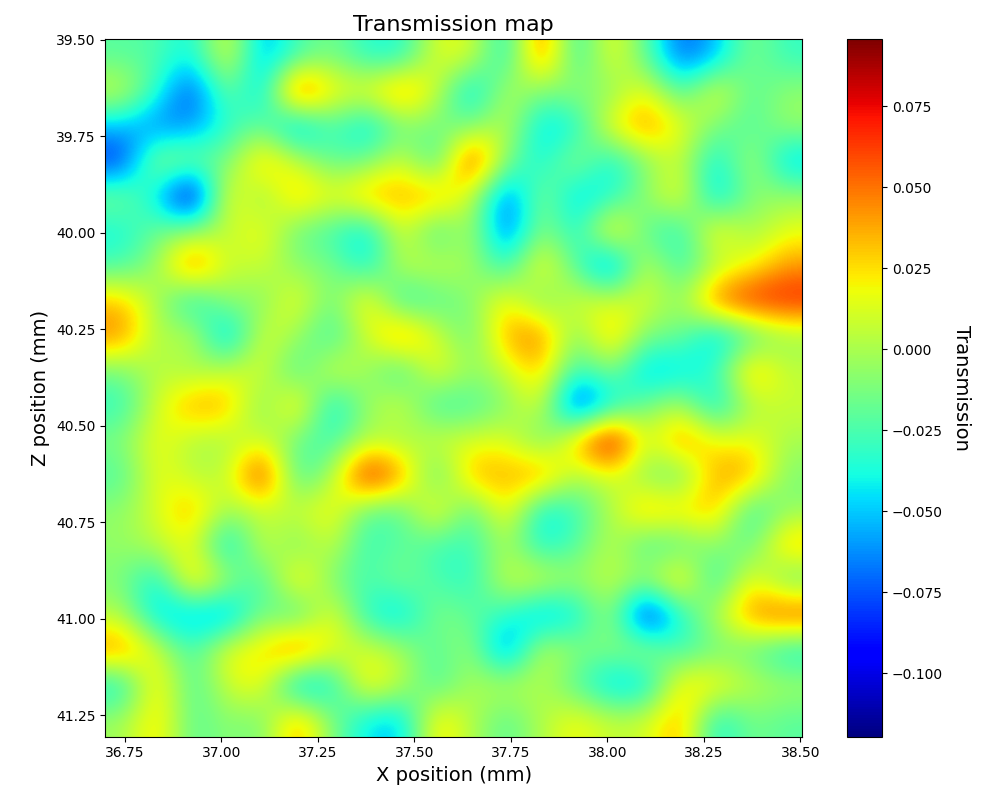

In [6]:
plot_transmission_map_from_singleh5(fileh5, proc)

**Plot average SAXS image**

✅ SAXS image saved: test_data/SWING_fev2026/example_emma_rods/saxs_images/S0000_M0119_Img_180.png


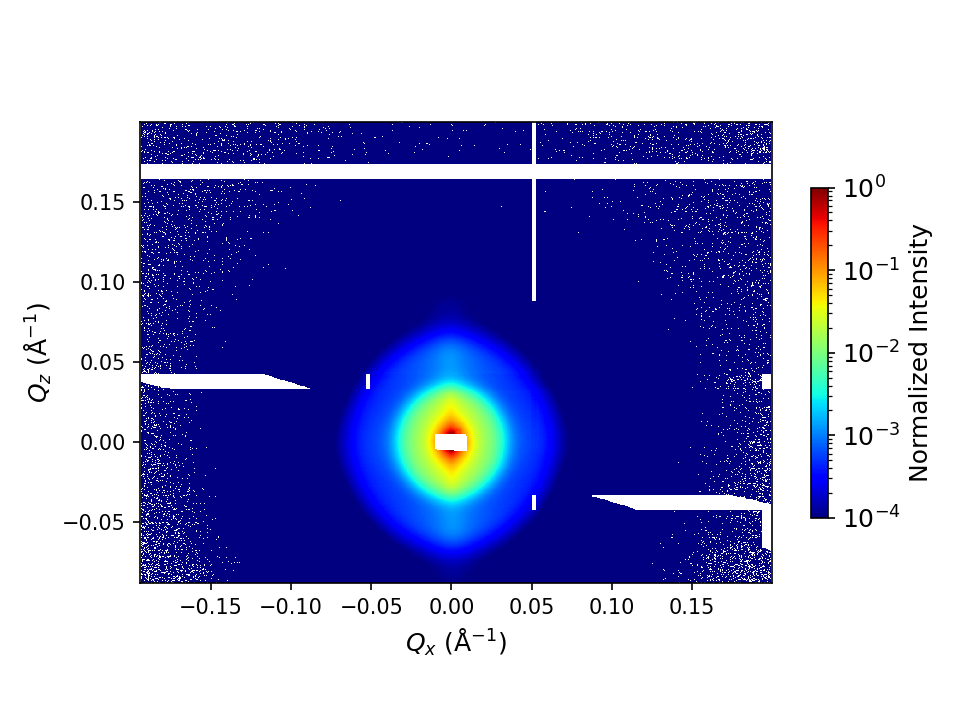

In [7]:
# Use dedicated function to plot average SAXS image
proc.plot2d_vsq()

**Plot and save average radial profile**

From the image above, we can define a q range of interest. This q range can also be determined by plotting the radial profile.
Let's do this first.
Note that the knowledge of this q range is critical for the determination of correlation distances, as it strongly affects results

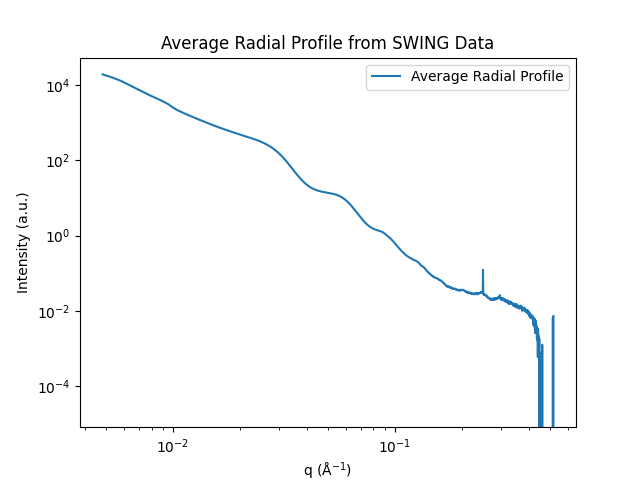

In [8]:
# Plot radial profile for average data
output_dir = os.path.join(proc.path,'average_radial_profile')
q,Ir = proc.extract_radial_profile(azimuth=0, width=360,output_dir=output_dir)

plt.figure()
plt.loglog(q, Ir, label='Average Radial Profile')
plt.xlabel('q (Å$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Average Radial Profile from SWING Data')
plt.legend()

## Determination of correlation peak

**Knowledge of working q range**

The algorithm for the determination of correlation peak requires the knowledge of workin q range (between qmin and qmax). If qmax is not set,the algorithm may focus on the noisy high q range signal. qmax=0.15 may be a good option. Alos qmin should be considered with care. The user is allowed to play with the algorithm parameters until satisfactory results are obtained.

**Hybrid Method**

Here we use a hybrid method using advantages of 2 methods:
- 2nd derivative method is used to identify peak positions (fast and efficient)
- each peak is refined using Split Pseudo Voigt functions to ensure accurate determination of correlation distance (peak identification with this method is not optimum)

There is a large number of arguments in the function. The most relevants are the followings:
- qmin and qmax defining the q window
- nb_peaks defining the number of peaks to search in the specified q window
- method = 'hybrid', 'spv', or 'derivative' depending on the method selected for the computation
- substract_power_law (bool)
- fit_window_width


Playing with these parameters should be enough to obtain satisafctory results. In cas of issues, read dedicated documentation (file parameter_guide.py).


In [ ]:
get_results = detect_peaks_hybrid_interactive(
    proc,
    nb_peaks_init=2,
    qmin_init=0.03,
    qmax_init=0.15,
    fit_window_width_init=1,
    prominence=0.8,
    distance_pts=20)




Output()

In [10]:
# Après avoir ajusté les sliders, récupérer les résultats
results_dict = get_results()
distances = results_dict['distances']
distances_std = results_dict['distances_std']
hybrid_results = results_dict['hybrid_results']
peaklist = results_dict['peaklist']


print(peaklist)



[0.0572206  0.08753655]


## Nematic order parameter

**Selection of working qvalue**

We select the first pealk returned by the calculation of correlation distances

In [11]:
qvalues = peaklist

**Form factor parameters**

**Form factor parameters**

Used for nematic order calculation

Either define it yourself, or you can use the parameters extracted from the excel file.

In [12]:
# If you didn't use the function to extract parameters from excel (get_all_params), you can directly set your parameters here:
# L = 1000
# radius = 100 
# radius_pd = 0.2
# L_pd=1.7  # polydispersity on length is huge!


# If you did use the function to extract parameters from excel (get_all_params), you can use the extracted parameters here:
L = length * 10  # convert nm to Å
radius = diameter * 10 / 2  # convert nm to Å
radius_pd = polydispersity_d * 0.01 # convert percent to fraction
L_pd = polydispersity_L * 0.01 # convert percent to fraction

**Nematic Order Calculation**

It is computed for the first peak



Azimuthal profile completeness check:
  Status: COMPLETE
  Profile is complete (no NaN/zero values)
  → Mirror symmetry: DISABLED
Main nanorod orientation is -0.31347193641414606

Computing cylinder form factor...


c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\pyopencl\cache.py:517: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  _create_built_program_from_source_cached(


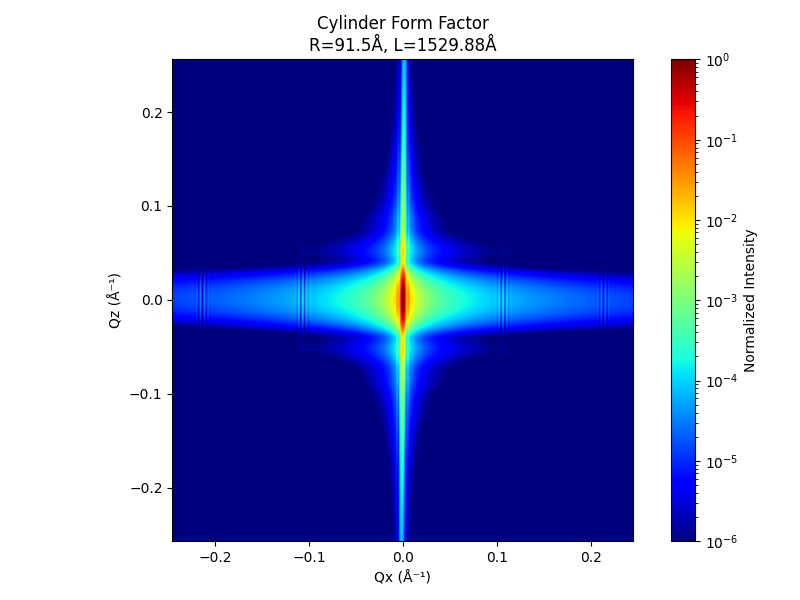


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in test_data/SWING_fev2026/example_emma_rods\azimuthal_profiles\S0000_M0119_B=0_Img180_nematic_determination.png

Fitting results:
x0: -90.16899614256181
S: 0.8845649518636154
R2: 0.9657575827044744

Azimuthal profile completeness check:
  Status: COMPLETE
  Profile is complete (no NaN/zero values)
  → Mirror symmetry: DISABLED
Main nanorod orientation is -0.31347193641414606

Computing cylinder form factor...


c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\sasmodels\kernelcl.py:469: RepeatedKernelRetrieval: Kernel 'cylinder_Iq' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  functions = [getattr(program, k) for k in names]
c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\sasmodels\kernelcl.py:469: RepeatedKernelRetrieval: Kernel 'cylinder_Iqxy' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  functions = [getattr(program, k) for k in names]
c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\sasmodels\kernelcl.py:469: RepeatedKernelRetrieval: Kernel 'cylinder_Imagnetic' has been retrieved more than once. E

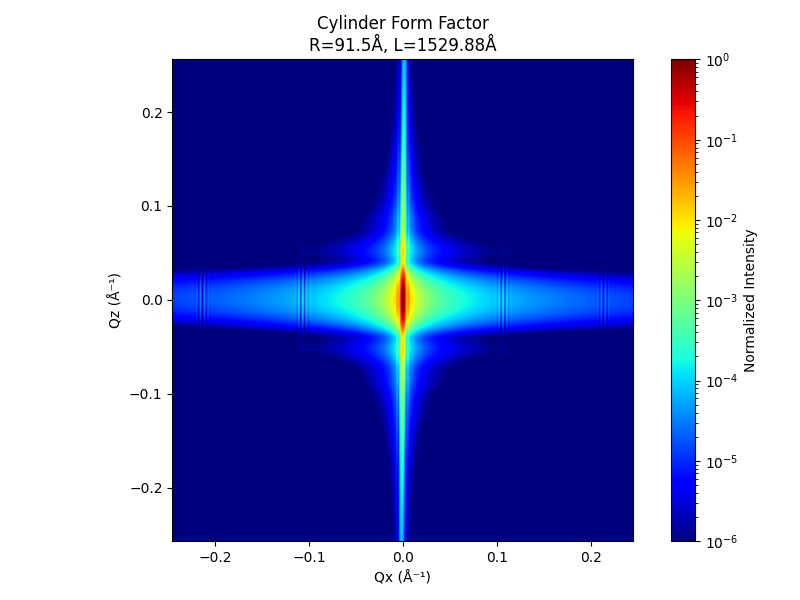


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in test_data/SWING_fev2026/example_emma_rods\azimuthal_profiles\S0000_M0119_B=0_Img180_nematic_determination.png

Fitting results:
x0: -90.16899614256181
S: 0.8845649518636154
R2: 0.9657575827044744


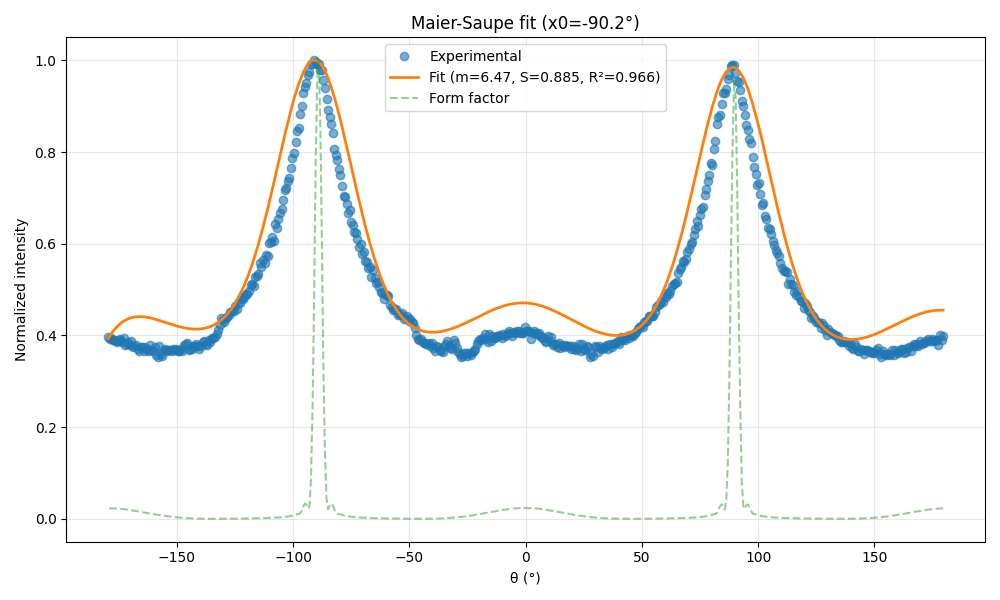

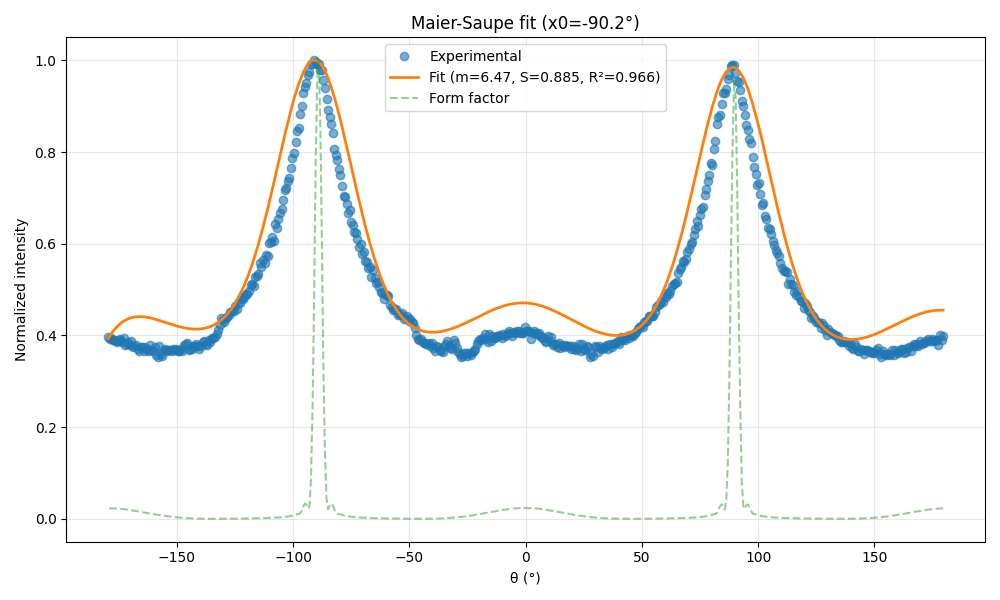

In [13]:
threshold = 0.01
plot = True
apply_mirror = False 
verbose = False

#calcul de S pour tous les pics
'''
S_array = np.zeros(len(qvalues))
for i, qvalue in enumerate(qvalues):
    S, mean_angle, dict = compute_nematic_parameter(
        processor = proc,
        qvalue = qvalue, 
        threshold = threshold,
        radius = radius,
        L = L,
        radius_pd = radius_pd,
        L_pd= L_pd,
        plot = plot,
        verbose = True
        )
    S_array[i] = S'''

#calcul de S le premier pic
S_array = np.zeros(len(qvalues))
mean_orientation_array = np.zeros(len(qvalues))
for i, qvalue in enumerate(qvalues):
    S, mean_angle, dict = compute_nematic_parameter(
            processor = proc,
            qvalue = peaklist[0], 
            threshold = threshold,
            radius = radius,
            L = L,
            radius_pd = radius_pd,
            L_pd= L_pd,
            plot = plot,
            verbose = True
            )
    S_array[i] = S
    mean_orientation_array[i] = mean_angle





## Store results in a dict or csv???

**Metadata**

Dans les exemple de data SWING à notre disposition, on ne fait pas varier le champ magnétique.

J'ai ajouté à la classe h5File_Swing une méthode pour extraire la valeur de B de l'attribut samplename.

Lors de l'acquisition des data, au moment de remplir le champ de référence échantillon, il vous faudra ajouter le champ B à la réf échantillon sous un format de style **'*_xxxmT*'**. 
 
 A la lecture du fichier h5, on aura alors accès à la valeur de B via l'attribut B de SAXSProcessor.

**Stockage csv**

J'ai ici indiqué un chemin vers un fichier csv fictif. A modifier


In [16]:
# save data in dictionary

results={
    'samplename': proc.samplename,
    'B (mT)': proc.B,
    'distance (A)': distances, # array of distances
    'distance_error (A)': distances_std, # array of errors
    'nematic_parameter': S_array, # array of nematic order parameters
    'mean_orientation': mean_orientation_array
}

# add dictionary to existing csv or create new one
csv_file = os.path.join(proc.path,'analysis_results.csv') 
if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_new = pd.DataFrame([results])
    df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    df_combined.to_csv(csv_file, index=False)
    # visualize added line
    print(df_new)
else:
    df = pd.DataFrame([results])
    df.to_csv(csv_file, index=False)


    samplename  B (mT)                             distance (A)  \
0  S0000_M0119       0  [109.80634567074712, 71.77784640173479]   

                        distance_error (A)  \
0  [5.490317283537356, 3.5888923200867398]   

                          nematic_parameter  \
0  [0.8845649518636154, 0.8845649518636154]   

                               mean_orientation  
0  [-0.31347193641414606, -0.31347193641414606]  


## Batch function

All these steps have been wrapped up in a single function "global_analyis", that could be further used for batch analysis. 
This function takes a total of 31 arguments, decomposed as follows:
- 1 arg for csv_file path where results are stored (csv_file)
- 2 args to define the list of files to be analyzed (h5path, prefix='lacroix')
- 4 args to initialize SAXSProcessor instance (mask, referencefile=None, k=1, autosubstract=True)
- 17 args(!) to initialize the hybrid method for correlation distance calculation. (mandatory ones: nb_peaks, qmin, qmax -- other parameters can keep their default value as a start)
- 5 args for nematic order calculation (radius, L, radius_pd, L_pd, threshold) - mostly used for form factor calculation
- 2 args for output (plot, verbose)

SUMMARY: There are 10 mandatory arguments:
- csv_file: path to file where results are appended
- h5path: path to data directory
- mask: path to mask file (pyfai edf format)
- nb_peaks: number of peaks for correlation distance determination
- qmin (=0.01) - qmax (=0.15): fitting window for correlation distance determination
- Form factor parameters (radius, L, radius_pd, L_pd)


Processing file: lacroix_00179_2026-02-06_14-04-10.nxs


c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Measurement name found: M0118 for index of h5 file 179.0

Processing file: lacroix_00180_2026-02-06_14-31-57.nxs


c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Measurement name found: M0119 for index of h5 file 180.0
position moteur :
{'X_start': array([36.6997]), 'X_end': array([38.5999]), 'Z_start': array([39.4995]), 'Z_end': array([41.4003])}
{'X_start': array([36.6997]), 'X_end': array([38.5999]), 'Z_start': array([39.4995]), 'Z_end': array([41.4003])}
step :
[0.09501]
[0.09504]
1
Raw data shape: (20, 20, 1083, 1035)
info
1083
1035
position moteur :
{'X_start': array([36.6997]), 'X_end': array([38.6]), 'Z_start': array([39.4996]), 'Z_end': array([41.4003])}
{'X_start': array([36.6997]), 'X_end': array([38.6]), 'Z_start': array([39.4996]), 'Z_end': array([41.4003])}
step :
[0.095015]
[0.095035]
1
Raw data shape: (20, 20, 1083, 1035)
info
1083
1035
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Optimized k factor for reference subtraction: 0.7830794
(1083, 1035)
✅ SAXS image saved: test_data/SWING_fev2026/example_emma_rods/saxs_ima

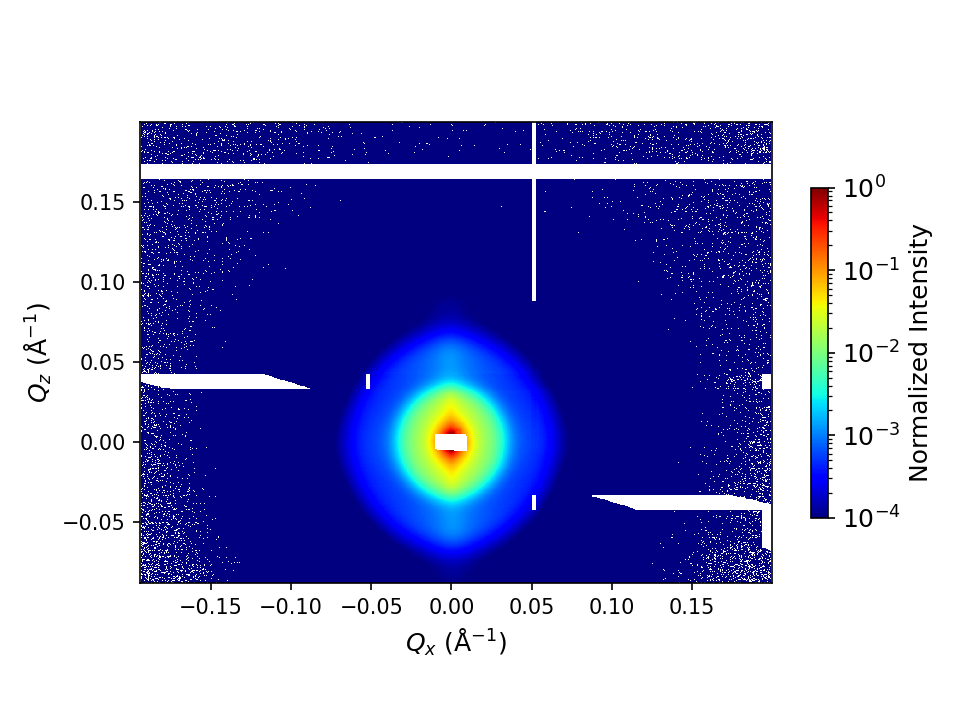


Analyse de Distance de Corrélation
Échantillon : S0000_M0119
Méthode     : HYBRID
Secteur     : 90° ± 15.0°

2 pic(s) détecté(s) :
  Pic 1:
    Dérivée : q = 0.0269 Å⁻¹
    SPV     : q = 0.0269 ± 0.0013 Å⁻¹ → d = 233.5 ± 11.7 Å
    Δq = 0.0000 Å⁻¹ (0.00%)
    FWHM = 0.0175 Å⁻¹
  Pic 2:
    Dérivée : q = 0.0577 Å⁻¹
    SPV     : q = 0.0577 ± 0.0029 Å⁻¹ → d = 108.8 ± 5.4 Å
    Δq = 0.0000 Å⁻¹ (0.00%)
    FWHM = 0.0442 Å⁻¹

Ordre loi de puissance : m = 4.33

Azimuthal profile completeness check:
  Status: INCOMPLETE
  Found 2 gap(s) with invalid data:
    Gap 1: between χ=-0.4° and χ=0.3° (1 points)
    Gap 2: between χ=89.6° and χ=90.2° (1 points)
  → Mirror symmetry: ENABLED
Main nanorod orientation is 2.42238753298534

Computing cylinder form factor...


c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\pyFAI\integrator\azimuthal.py:615: RuntimeWarning: invalid value encountered in divide
  intensity = sum_signal / sum_normalization



Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q

Fitting results:
x0: 88.327133151873
S: 0.8992869707104103
R2: 0.9381840045764367

Azimuthal profile completeness check:
  Status: INCOMPLETE
  Found 2 gap(s) with invalid data:
    Gap 1: between χ=-0.4° and χ=0.3° (1 points)
    Gap 2: between χ=89.6° and χ=90.2° (1 points)
  → Mirror symmetry: ENABLED
Main nanorod orientation is 2.42238753298534

Computing cylinder form factor...

Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q

Fitting results:
x0: 88.327133151873
S: 0.8992869707104103
R2: 0.9381840045764367
The following line     samplename  B (mT)                                 q_peak (A⁻¹)  \
0  S0000_M0119       0  [0.026904652186760993, 0.057734432625465

In [17]:
excel_file = "Run_synchrotron_SOLEIL_02_2026_suivi_manips.xlsm" # path to the excel file containing the parameters 
pathh5 = 'test_data/SWING_fev2026/example_emma_rods/' # path to the folder containing the h5 files (probably the same as bg_path)
mask = "test_data/SWING_fev2026/mask_pyfai_nico.edf" # mask generated by Nicolas directly (edf format)
csv_results_path = os.path.join(pathh5,'analysis_results_batch.csv') # your path
instrument='SWING'

# OLD CODE: not generalized
# If you don't want to use the function that extracts parameters from the excel file (get_all_params), you can directly set your parameters here and run the global analysis:
# results = global_analysis(
#     csv_file=csv_file,
#     h5path=pathh5,
#     reference_file= reference_file, # new param
#     autosubstract=True,
#     mask=mask,
#     nb_peaks=2,
#     qmin=0.02,
#     qmax=0.09,
#     azimuth=90,
#     width=30,
#     method='hybrid',
#     radius=diameter * 10/2, # new param
#     L=length * 10,
#     radius_pd=polydispersity_d * 0.01, # new param
#     L_pd=polydispersity_L * 0.01,
#     plot=False,
#     verbose=False)



# ONGOING WORK: Generalize it more by finding automatically the parameters from the excel file and the h5path 
# Results file will be saved in the same folder as the h5 files, with the name "analysis_results_batch.csv". 
# It will contain the results for all the h5 files in the folder.
from excel_parameters_extractor import get_all_params
results = global_analysis(
    csv_file=csv_results_path,
    h5path=pathh5,
    excel_file=excel_file, # new param
    instrument=instrument,
    autosubstract=True,
    mask=mask,
    nb_peaks=2,
    qmin=0.02,
    qmax=0.09,
    azimuth=90,
    width=30,
    method='hybrid',
    # in the case you use the excel to find it automatically, you can set radius and L to None, and it will be done in the function using the get_all_params function
    radius= None, 
    L= None,
    plot=False,
    verbose=False)



### **NEW: Make a final dataframe with all the parameters for a measurement**

The function **final_dataframe(h5path, excel_file, csv_results_path)** creates a dataframe with all the parameters from the excel file and the csv results (d, S) for all the h5 files in a folder.

How?: It concatenates the two sheets *SAMPLES* and *MEASUREMENTS* from the excel file with the results from the csv file.
    
**Parameters**:

- *h5path* : str, path of the h5 folder 
- *excel_file* : str, path of the excel file containing the experiment informations
- *csv_results_path*: str, path of the csv file containing the results

**Notes**:
- 1. The indexes of the h5 files must be in *FILE* column in *MEASUREMENTS* sheet of the excel file. 
For example: for file *lacroix_00782_2024-07-20_02-32-08.h5*, it must be written as "00782" in the "FILE" column of the excel.
- 2. Should work with the current format of results CSV, with the column *samplename* containing the name of the measurement as "S0001_M0001"
- 3. Uses 2 peaks by default, maybe not the best (verify the impact of this parameter)

In [18]:
from excel_parameters_extractor import  final_dataframe

excel_file = "Run_synchrotron_SOLEIL_02_2026_suivi_manips.xlsm" # path to the excel file containing the parameters 
pathh5 = "test_data/SWING_fev2026/example_emma_rods/" # your path
csv_results_path = os.path.join(pathh5,'analysis_results.csv') # your path

final_dataframe(pathh5, excel_file, csv_results_path)

ID found in h5path: 179.0
ID found in h5path: 180.0
sample_name S0000_M0119
 Found multiple S0000_M0119 in the results csv file, take first (index 0)
S value =  [0.88456495 0.88456495] type of S value =  <class 'str'>
S array =  [0.88456495 0.88456495] type of S array =  <class 'numpy.ndarray'>
distance [A] =  [109.80634567  71.7778464 ] type of distance value =  <class 'str'>
d array =  [109.80634567  71.7778464 ] type of d array =  <class 'numpy.ndarray'>


c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\saram\anaconda3\envs\debye3d_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,NAME,SAMPLE,REFERENCE,FILE,EXPERIMENT NATURE,ULTRASOUND?,DISPERSION SOLVENT NATURE,START X,SLOT,STEP,...,POLYDISPERSITY L [%],CHLOROFORM,DICHLOROMETHANE,ISOPROPANOL,ABSOLUTE ETHANOL,TOLUENE,THF,S MEAN,nematic_parameter,distance (A)
0,M0119,S0000,M0118,180.0,Flow cell,Yes,Anisole,"36,7",20.0,"0,1",...,15.69,3.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0.88456495, 0.88456495]","[109.80634567, 71.7778464]"
